In [1]:
import scanpy as sc
import numpy as np
import flowkit as fk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from preprocessing import read_flow
fcs_dir = str(input("Path"))
tissue_type = fcs_dir[:3]
df_flow, sample_list, session = read_flow(fcs_dir)

Path LLN_T7_exported CD45AF


In [ ]:
exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'Time', 'SSC-B-A', "SSC-B-H", "AF-A", 'CD66bCD19CD326LD', 'CD45']
df_flow = df_flow.drop(columns=exclude)

In [8]:
from scipy.stats import zscore
z_scores = df_flow.select_dtypes(include='number').apply(zscore)
outliers = df_flow[(z_scores > 3).any(axis=1)]
df_flow = df_flow[(z_scores < 3).all(axis=1)]

In [9]:
df_flow_counts = df_flow.select_dtypes(include=[np.number])

In [ ]:
from preprocessing import pd_to_adata
adata = pd_to_adata(df_flow, df_flow_counts)

In [12]:
sc.pp.scale(adata, max_value=5)

In [13]:
CD3 = adata[(adata[:, 'CD3'].X > 0)]
CD3 = CD3[:, CD3.var.index != 'CD3']
adata_list = [
    CD3[CD3.obs['group'] == group].copy()[np.random.choice(
        CD3[CD3.obs['group'] == group].shape[0], 20000, replace=False
    )]
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3 = sc.AnnData.concatenate(*adata_list, index_unique=None)

/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_2796/2760585910.py:11: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_list[i].obs['group'] = group
/tmp/ipykernel_2796/2760585910.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  CD3 = sc.AnnData.concatenate(*adata_list, index_unique=None)
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/a

In [14]:
adata = adata[:, adata.var.index != 'CD3']
adata

View of AnnData object with n_obs × n_vars = 68311269 × 23
    obs: 'group', 'sample_id'
    var: 'mean', 'std'

In [15]:
gdTCR = adata[(adata[:, 'gdTCR'].X > 0)]
gdTCR = gdTCR[:, gdTCR.var.index != 'gdTCR']
gdTCR = gdTCR[:, gdTCR.var.index != 'TCRva']
adata_list = [
    gdTCR[gdTCR.obs['group'] == group].copy()[np.random.choice(
        gdTCR[gdTCR.obs['group'] == group].shape[0], 20000, replace=False
    )]
    for group in ['ctr', 'hst', 'ftl']
]

# Set the group column for each subset
for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

# Concatenate without specifying a batch_key
gdTCR = sc.AnnData.concatenate(*adata_list, index_unique=None)

/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_2796/380531687.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_list[i].obs['group'] = group
/tmp/ipykernel_2796/380531687.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  gdTCR = sc.AnnData.concatenate(*adata_list, index_unique=None)
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/a

In [16]:
TCRva = adata[(adata[:, 'TCRva'].X > 0)]
TCRva = TCRva[:, TCRva.var.index != 'gdTCR']
TCRva = TCRva[:, TCRva.var.index != 'TCRva']
adata_list = [
    TCRva[TCRva.obs['group'] == group].copy()[np.random.choice(
        TCRva[TCRva.obs['group'] == group].shape[0], 20000, replace=False
    )]
    for group in ['ctr', 'hst', 'ftl']
]

# Set the group column for each subset
for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

# Concatenate without specifying a batch_key
TCRva = sc.AnnData.concatenate(*adata_list, index_unique=None)

/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_2796/3690136633.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_list[i].obs['group'] = group
/tmp/ipykernel_2796/3690136633.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  TCRva = sc.AnnData.concatenate(*adata_list, index_unique=None)
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core

In [ ]:
CD4 = adata[(adata[:, 'CD4'].X > 0)]
CD4 = CD4[:, CD4.var.index != 'gdTCR']
CD4 = CD4[:, CD4.var.index != 'TCRva']
CD4 = CD4[:, CD4.var.index != 'CD4']
CD4 = CD4[:, CD4.var.index != 'CD8']
adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD4[CD4.obs['group'] == group].copy()
    num_cells = group_data.shape[0]
    
    if num_cells >= 20000:
        sampled_data = group_data[np.random.choice(num_cells, 20000, replace=False)]
    else:
        print(f"Group '{group}' has only {num_cells} cells; using all cells instead.")
        sampled_data = group_data  # Use all available cells if fewer than 20,000
    
    sampled_data.obs['group'] = group  # Ensure the group column is correctly set
    adata_list.append(sampled_data)

# Concatenate without specifying a batch_key
CD4 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [18]:
CD8 = adata[(adata[:, 'CD8'].X > 0)]
CD8 = CD8[:, CD8.var.index != 'gdTCR']
CD8 = CD8[:, CD8.var.index != 'TCRva']
CD8 = CD8[:, CD8.var.index != 'CD4']
CD8 = CD8[:, CD8.var.index != 'CD8']
adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD8[CD8.obs['group'] == group].copy()
    num_cells = group_data.shape[0]
    
    if num_cells >= 20000:
        sampled_data = group_data[np.random.choice(num_cells, 20000, replace=False)]
    else:
        print(f"Group '{group}' has only {num_cells} cells; using all cells instead.")
        sampled_data = group_data  
    
    sampled_data.obs['group'] = group
    adata_list.append(sampled_data)
CD8 = sc.AnnData.concatenate(*adata_list, index_unique=None)

/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_2796/3208094405.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sampled_data.obs['group'] = group
/tmp/ipykernel_2796/3208094405.py:19: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  CD8 = sc.AnnData.concatenate(*adata_list, index_unique=None)
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ubuntu/.local/lib/python3.11/site-packages/anndata/_core/an

In [156]:
sample = CD8
sample_name = 'CD8'

In [157]:
sc.settings.verbosity = 3

In [158]:
plt.rcParams.update({'font.size': 10})  

computing PCA
    with n_comps=18
    finished (0:00:00)


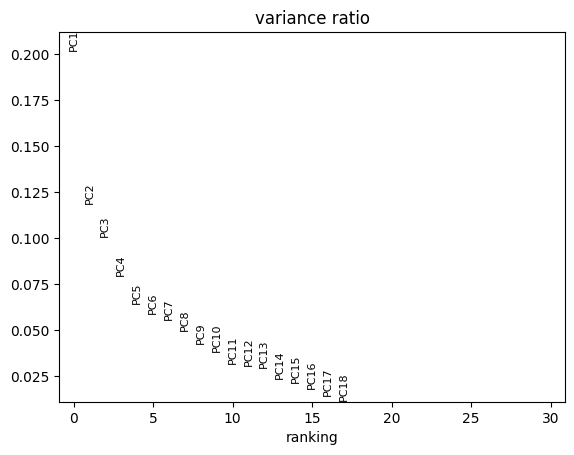

In [159]:
sc.tl.pca(sample, svd_solver="arpack")
sc.pl.pca_variance_ratio(sample, log=False)

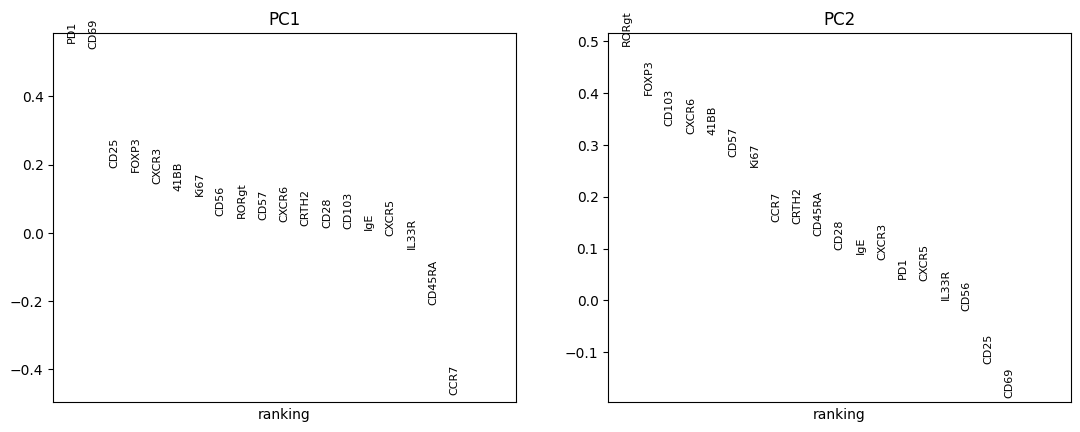

In [201]:
sc.pl.pca_loadings(sample, components = '1,2')

In [161]:
sample_list = session.get_sample_ids()

In [162]:
pca_df = pd.DataFrame(sample.obsm['X_pca'], columns=[f'PC{i+1}' for i in range(sample.obsm['X_pca'].shape[1])])
pca_df['sample_id'] = sample.obs['sample_id'].values

grouped_pca = pca_df.groupby('sample_id').mean()

donor_groups = []
for sample_id in sample_list:
    if "ctr" in sample_id:
        donor_groups.append('ctr')
    elif "hst" in sample_id:
        donor_groups.append('hst')
    elif "ftl" in sample_id:
        donor_groups.append('ftl')

In [163]:
pca_df['sample_id'].unique()

array(['d457', 'd565', 'd319', 'd516', 'd566', 'd559', 'd543', 'd568',
       'd530', 'd537', 'd579', 'd117', 'd274', 'd557', 'd567', 'd466',
       'd448', 'd562', 'd538', 'd137', 'd541', 'd544', 'd572', 'd534',
       'd465', 'd519', 'd377', 'd576', 'd483', 'd504', 'd142', 'd397',
       'd526', 'd237', 'd536', 'h152', 'd421', 'd564', 'd506', 'd545',
       'd558', 'd546', 'd507', 'd552', 'd601', 'd287', 'd524', 'd569',
       'd573', 'd532', 'd425', 'd512', 'd241', 'd335', 'd454', 'd220',
       'd493', 'd452'], dtype=object)

In [164]:
grouped_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
sample_id,,,,,,,,,,,,,,,,,,
d117,0.303574,-1.596654,0.397280,-1.108785,-0.358265,-0.390925,-0.328890,0.113614,0.501113,0.222728,-0.356405,-0.122615,-0.036294,0.194883,0.067032,0.159726,-0.123718,-0.038611
d137,0.737233,-0.611978,0.897294,0.401092,0.977788,0.329627,0.066516,0.091061,-0.203002,-0.121126,0.015904,-0.222850,0.474182,-0.095796,-0.004664,-0.080885,0.337444,0.350673
d142,-0.717074,-1.696117,-0.145425,-1.614023,-0.727446,0.140180,-0.412680,-0.484910,0.317783,-0.180543,-0.360853,-0.001285,-0.417736,-0.191640,-0.068845,-0.150935,-0.074187,0.055982
d220,1.282901,-1.058166,0.208688,0.174884,0.892835,0.665219,0.069472,1.169977,0.572508,0.659579,0.552355,0.702993,-0.021069,0.442042,0.108423,-0.473828,0.198642,0.016755
d237,-0.511244,-0.009740,0.622779,0.150469,0.599020,-0.107810,-0.189807,-0.203512,0.229573,-0.264083,-0.219380,0.476252,0.119213,-0.257991,-0.133030,-0.149615,-0.084443,0.047906
d241,1.151432,-0.421177,-0.081000,0.201268,0.040153,0.410355,-0.283595,-0.135672,-0.081427,-0.020710,0.005251,0.055154,-0.191028,-0.067300,0.016796,-0.031180,-0.023573,-0.051254
d274,-1.043730,-0.201801,-0.384999,0.431945,-0.048033,-0.470078,-0.250158,0.342574,0.116880,-0.553429,0.295085,0.116648,0.256129,-0.263642,-0.199424,0.190790,0.054653,-0.332880
d287,0.119428,0.115908,-0.525782,0.195913,0.122381,-0.090734,-0.187311,-0.023604,-0.208824,0.077752,-0.068871,0.214745,-0.085530,0.163342,-0.108060,-0.098631,-0.021335,0.318135
d319,-1.509349,-0.054344,-0.371237,0.575747,-0.274716,-0.785021,-0.067910,0.563889,0.490233,-0.363971,0.146134,-0.018154,0.272320,-0.293480,0.000185,0.109882,0.000541,-0.091406


In [166]:
grouped_pca['donor_group'] = donor_groups

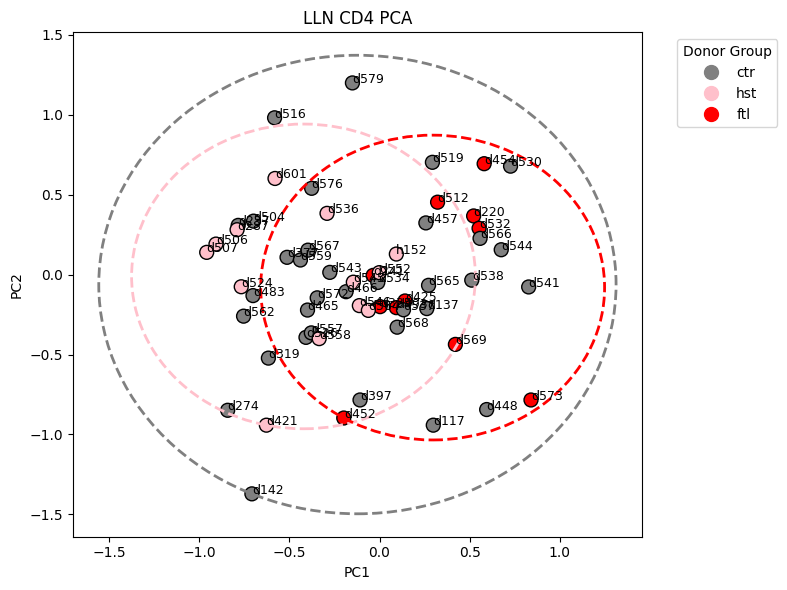

In [200]:
donor_colors = {
    'ctr': 'grey',
    'hst': 'pink',
    'ftl': 'red'
}

colors = grouped_pca['donor_group'].map(lambda x: donor_colors.get(x, 'black'))

plt.figure(figsize=(8, 6))
plt.scatter(grouped_pca['PC1'], grouped_pca['PC2'], c=colors, edgecolor='k', s=100)

for sample_id, (x, y) in grouped_pca[['PC1', 'PC2']].iterrows():
    plt.text(x, y, sample_id, fontsize=9)

for group, color in donor_colors.items():
    subset = grouped_pca[grouped_pca['donor_group'] == group]
    if not subset.empty:
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        max_distance = np.max(np.linalg.norm(subset[['PC1', 'PC2']].values - np.array([centroid_x, centroid_y]), axis=1))
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color, fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('{} {} PCA'.format(tissue_type, sample_name))

handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10) 
           for color in donor_colors.values()]
plt.legend(handles, donor_colors.keys(), title='Donor Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

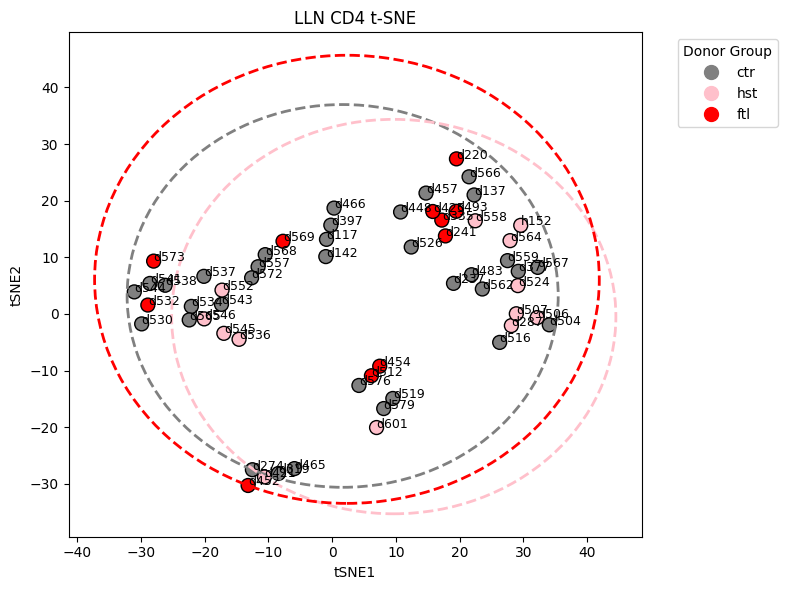

In [202]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0, perplexity = 5)
tsne_results = tsne.fit_transform(grouped_pca.iloc[:, :-1])

grouped_pca['tSNE1'] = tsne_results[:, 0]
grouped_pca['tSNE2'] = tsne_results[:, 1]

donor_colors = {
    'ctr': 'grey',
    'hst': 'pink',
    'ftl': 'red'
}

colors = grouped_pca['donor_group'].map(lambda x: donor_colors.get(x, 'black'))

plt.figure(figsize=(8, 6))
plt.scatter(grouped_pca['tSNE1'], grouped_pca['tSNE2'], c=colors, edgecolor='k', s=100)

for sample_id, (x, y) in grouped_pca[['tSNE1', 'tSNE2']].iterrows():
    plt.text(x, y, sample_id, fontsize=9)

for group, color in donor_colors.items():
    subset = grouped_pca[grouped_pca['donor_group'] == group]
    if not subset.empty:
        centroid_x, centroid_y = subset[['tSNE1', 'tSNE2']].mean()
        max_distance = np.max(np.linalg.norm(subset[['tSNE1', 'tSNE2']].values - np.array([centroid_x, centroid_y]), axis=1))
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color, fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.title('{} {} t-SNE'.format(tissue_type, sample_name))

handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10) 
           for color in donor_colors.values()]
plt.legend(handles, donor_colors.keys(), title='Donor Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:03)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:01)
--> added 'pos', the PAGA positions (adata.uns['paga'])


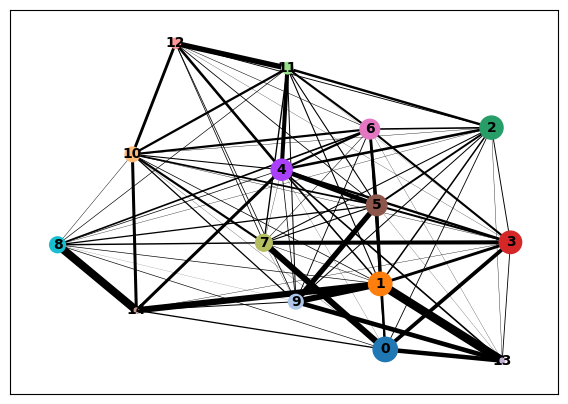

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:22)


In [203]:
sc.pp.neighbors(sample, n_neighbors=15, n_pcs= 15, random_state=0)
sc.tl.leiden(sample, resolution=0.8, flavor='leidenalg')
sc.tl.paga(sample)
sc.pl.paga(sample)
sc.tl.umap(sample, init_pos='paga', random_state=0)

In [204]:
markers = list(sample.var_names)

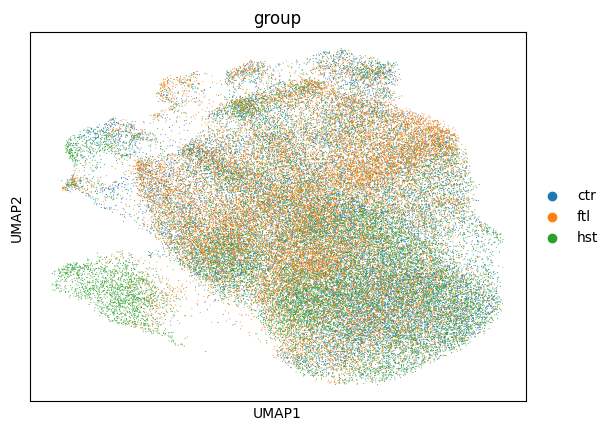

In [205]:
sc.pl.umap(sample, color= ['group'], cmap='turbo')


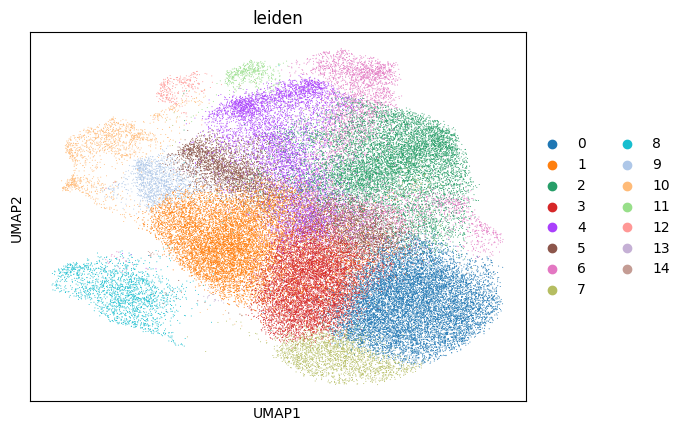

In [ ]:
sc.pl.umap(sample, color= ['leiden'], cmap='turbo')

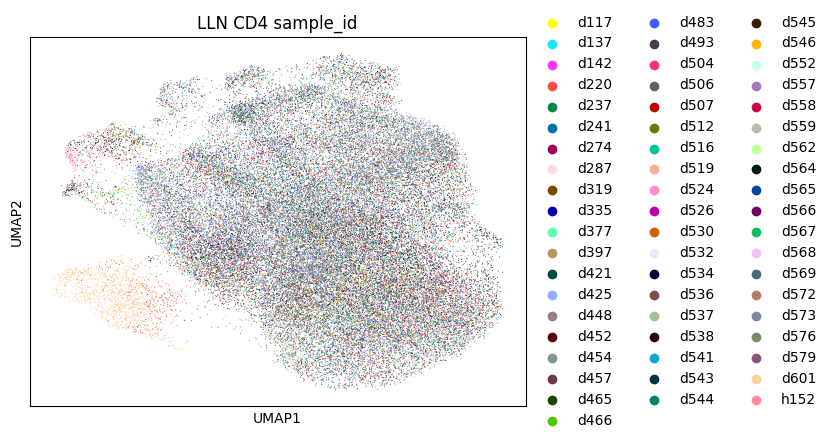

In [207]:
sc.pl.umap(sample, color= ['sample_id'], cmap='turbo', title = '{} {} sample_id'.format(tissue_type, sample_name))

In [221]:
plt.rcParams.update({'font.size': 14})  

# Generate UMAP plot and get the figure
fig = sc.pl.umap(sample, color=markers, cmap='turbo', show=False, return_fig=True)

# Save the figure
fig.savefig("umap_plot.png", dpi=300, bbox_inches='tight')

# Close the figure to free memory
plt.close(fig)


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


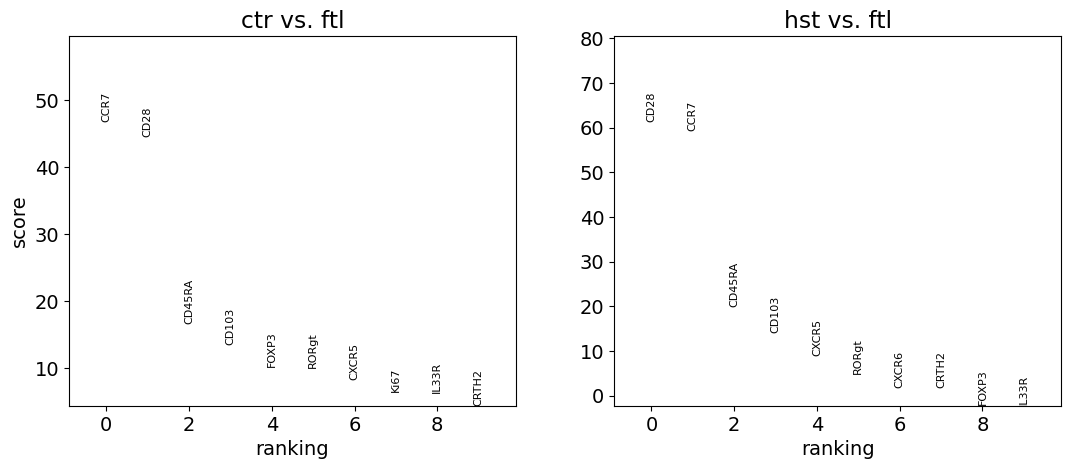

In [209]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['ctr','hst'], reference = 'ftl', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


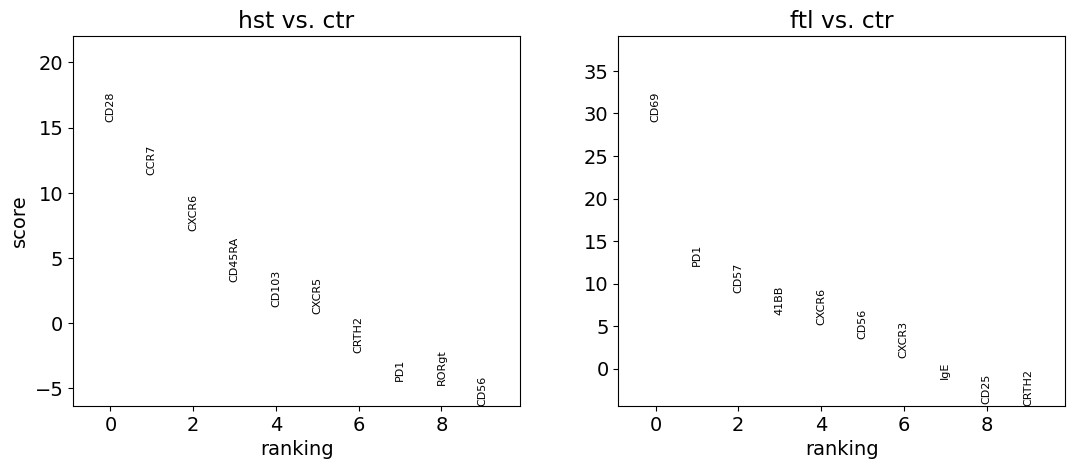

In [210]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['hst', 'ftl'], reference = 'ctr', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


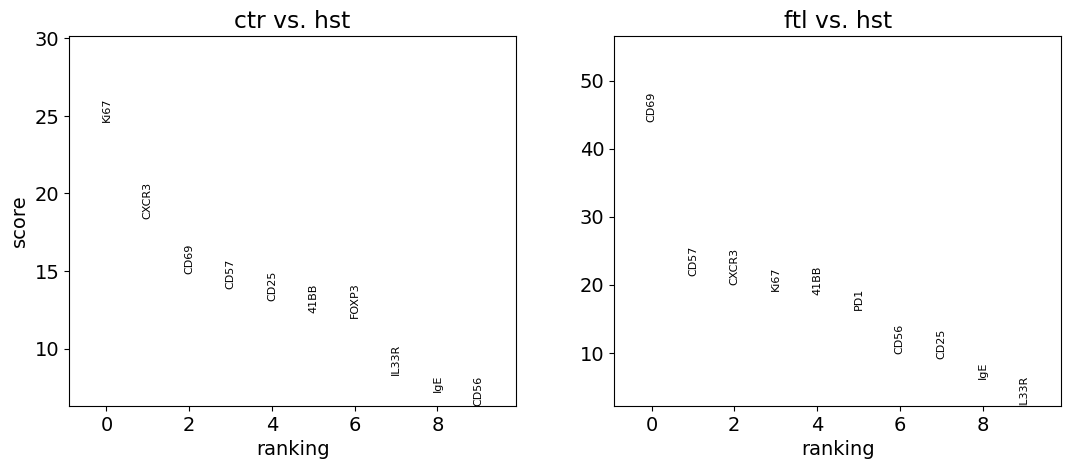

In [211]:
sc.tl.rank_genes_groups(sample, groupby='group', groups = ['ctr', 'ftl'], reference = 'hst', method='t-test')
sc.pl.rank_genes_groups(sample, n_genes=10, sharey=False)

In [212]:
sc.tl.rank_genes_groups(sample, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: sample.uns["rank_genes_groups"]["names"][group] for group in sample.uns["rank_genes_groups"]["names"].dtype.names}
)
df.head(3)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/.local/lib/python3.11/

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,CCR7,IL33R,CD69,Ki67,PD1,CD28,CD25,CD45RA,RORgt,CXCR3,CRTH2,CXCR6,CD57,CD103,CXCR6
1,CD45RA,41BB,PD1,CD45RA,CD28,CXCR3,FOXP3,CD103,CXCR6,IgE,RORgt,PD1,PD1,CXCR5,CD103
2,CD28,IgE,CD56,41BB,Ki67,CD103,PD1,CD57,FOXP3,CRTH2,CD103,CD69,CD69,CXCR6,CXCR3


In [213]:
result = sample.uns["rank_genes_groups"]
groups = result["names"].dtype.names

celltype = {'celltype': []}
cluster_to_genes = {}
for group in groups:
    top_genes = result["names"][group][:3]
    cluster_to_genes[group] = f"{':'.join(top_genes)} ({group})"

celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
sample.obs["celltype"] = celltype['celltype']

print(sample.obs[["leiden", "celltype"]].head())

        leiden              celltype
1037218      0  CCR7:CD45RA:CD28 (0)
613694       0  CCR7:CD45RA:CD28 (0)
1617929      1    IL33R:41BB:IgE (1)
1610934      0  CCR7:CD45RA:CD28 (0)
324227       9   CXCR3:IgE:CRTH2 (9)


In [214]:
plt.rcParams.update({'font.size': 10})  

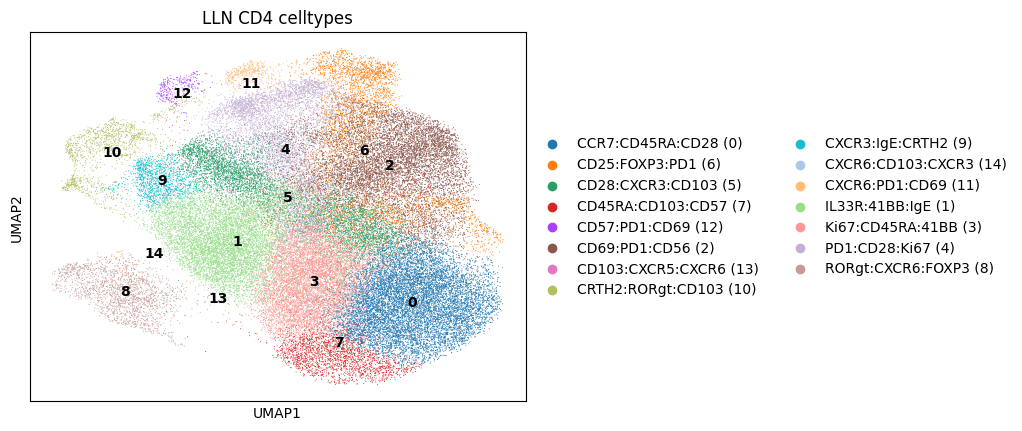

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

# Plot the UMAP
sc.pl.umap(
    sample,
    color=['celltype'],
    cmap='turbo',
    title = '{} {} celltypes'.format(tissue_type, sample_name),# Show legends directly on the UMAP
    show=False,            # Prevent immediate display
)

# Add cluster labels
ax = plt.gca()  # Get current axis
for cluster in sample.obs['leiden'].cat.categories:
    # Find the coordinates of cells in this cluster
    cluster_mask = sample.obs['leiden'] == cluster
    cluster_coords = sample.obsm['X_umap'][cluster_mask]
    # Calculate cluster centroid
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    # Add text label
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

# Display the plot
plt.show()

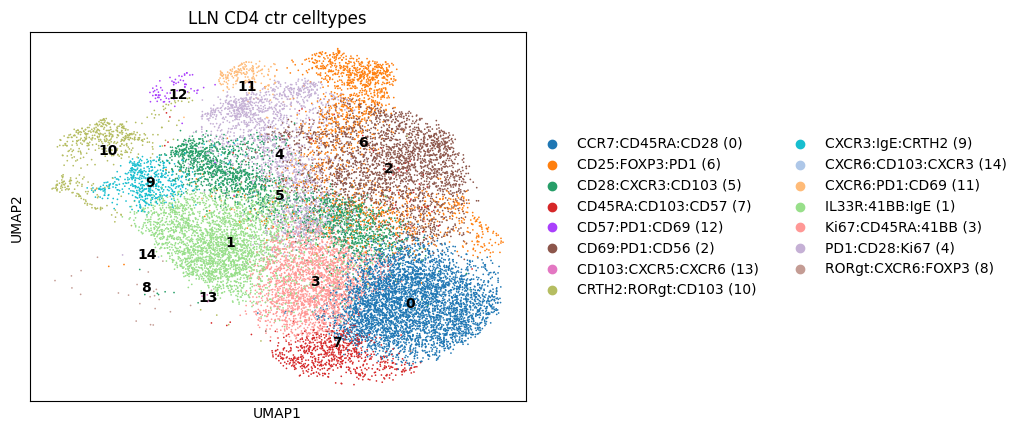

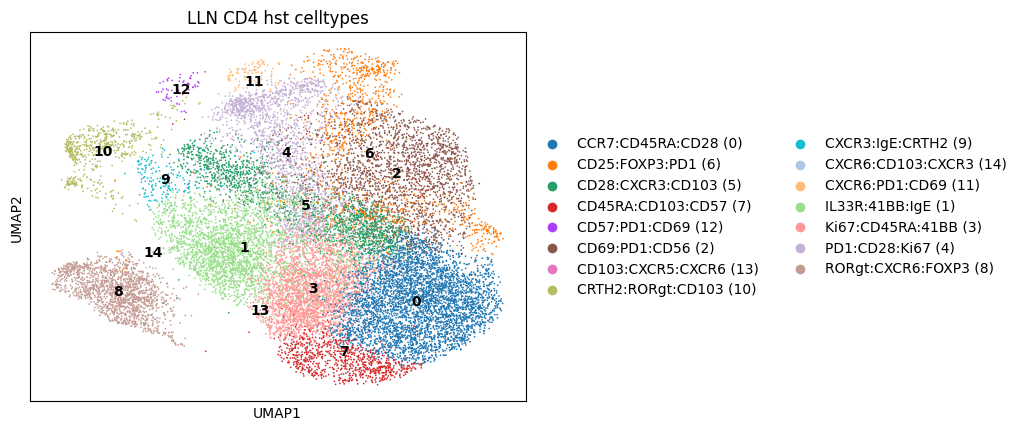

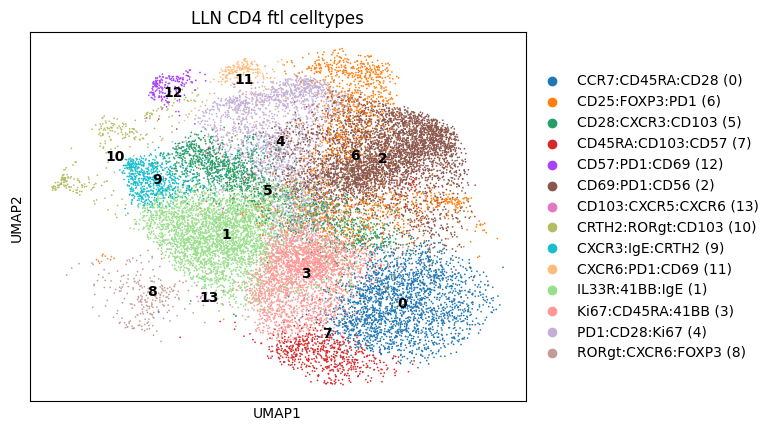

In [216]:
for group in ['ctr', 'hst', 'ftl']:
    adata_group = sample[sample.obs['group'] == group]
    
    sc.pl.umap(
    adata_group,
    color=['celltype'],
    title=f'{tissue_type} {sample_name} {group} celltypes',
    cmap='turbo', 
    show=False             
)

    ax = plt.gca()  
    for cluster in adata_group.obs['leiden'].cat.categories:
        cluster_mask = adata_group.obs['leiden'] == cluster
        cluster_coords = adata_group.obsm['X_umap'][cluster_mask]
        x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
        ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

    plt.show()

In [217]:
plt.rcParams.update({'font.size': 12})  

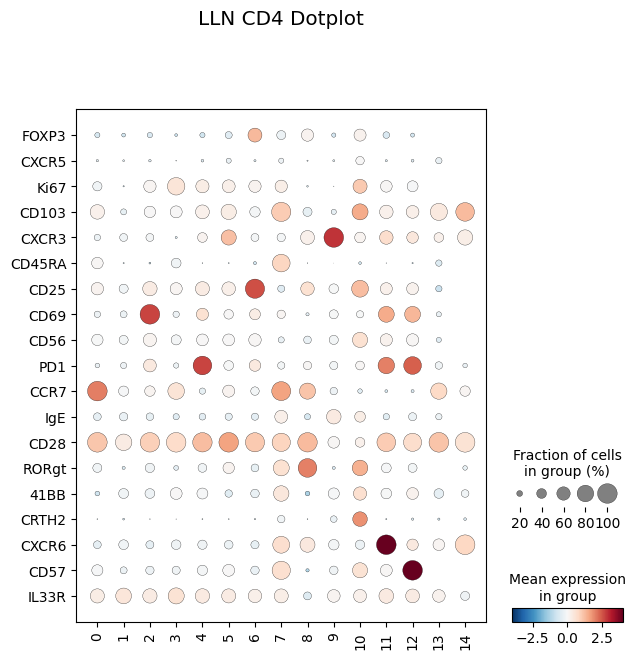

In [218]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

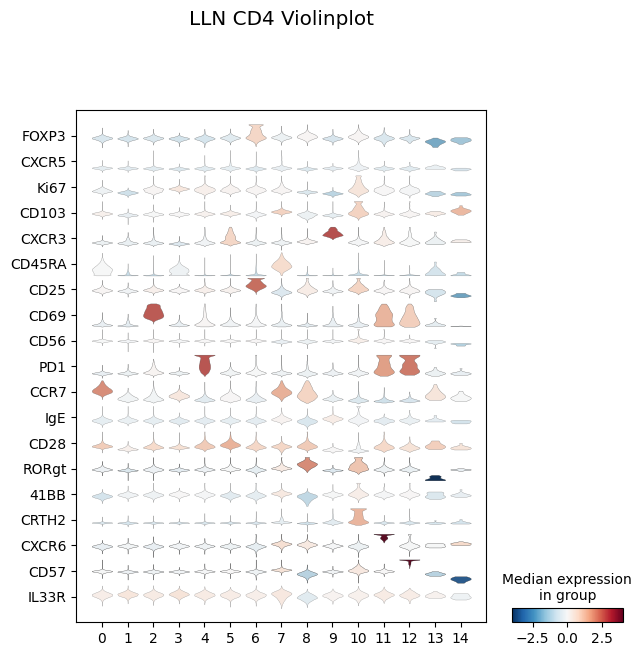

In [219]:
sc.pl.stacked_violin(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Violinplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)